In [4]:
!pip install -q transformers datasets accelerate scikit-learn

In [5]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU not found! Go to Runtime → Change runtime type → GPU"
    )

device = torch.device("cuda")
print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU: NVIDIA A100-SXM4-40GB


In [6]:
import pandas as pd

df = pd.read_csv('/content/result_dataset_balanced_56k.csv', engine='python', on_bad_lines='warn')
print(f"Dataset loaded with {len(df)} rows and {len(df.columns)} columns.")
df.head()

Dataset loaded with 56000 rows and 16 columns.


,rfq_id,rfq_title,rfq_description,quantity,delivery_location,category_id,rfq_supplier_types,supplier_name,supplier_country,distribution_area,supplier_description,supplier_types,products,product_categories,keywords,match_type
0,000e6a46-ac45-4489-b237-12c15f5fb9a7,"Korktaschen, Korkrucksäcke, Korkreisetaschen, ...",Ich bin auf der Suche nach\n product : ...,10 - 50,DE,100033.0,"{MANUFACTURER,WHOLESALER}","WHY NOT?, LDA.",PT,international,The journey of Why Not? Bags began with the cr...,"{Production,CustomerSpecificManufacturing}","{In-House Collection of Ready-to-Use Models,In...",{Clothing and accessories},"{Clothes and fashion model collections,High fa...",match
1,000e6a46-ac45-4489-b237-12c15f5fb9a7,"Korktaschen, Korkrucksäcke, Korkreisetaschen, ...",Ich bin auf der Suche nach\n product : ...,10 - 50,DE,100033.0,"{MANUFACTURER,WHOLESALER}",NY CORK,TR,international,The Nine Years is a premium Istanbul-based bra...,{Production},"{""CORPORATE GIFTS, HOME AND HOTEL SUPPLIES, WO...",{Design},"{cork bags,cork handbags,cork accessories,wome...",match
2,000e6a46-ac45-4489-b237-12c15f5fb9a7,"Korktaschen, Korkrucksäcke, Korkreisetaschen, ...",Ich bin auf der Suche nach\n product : ...,10 - 50,DE,100033.0,"{MANUFACTURER,WHOLESALER}","FARL CORK UNIPESSOAL, LDA",PT,international,FARL CORK is a company established in late 201...,{Production},"{Natural yoga block,Fine grain cork block - Yo...",{Wood and wood products},"{Cortiça - produtos,yoga,cortiça granulada,Rol...",match
3,000e6a46-ac45-4489-b237-12c15f5fb9a7,"Korktaschen, Korkrucksäcke, Korkreisetaschen, ...",Ich bin auf der Suche nach\n product : ...,10 - 50,DE,100033.0,"{MANUFACTURER,WHOLESALER}",EMPREMTA BARCELONA,ES,europe,"At Empremta Barcelona, we specialize in the sa...","{CustomerSpecificManufacturing,Wholesaler,Serv...",{Customizable polyester drawstring backpack 19...,"{""Marketing, advertising and sales""}","{Lightweight backpack,durable backpack,daily b...",match
4,000e6a46-ac45-4489-b237-12c15f5fb9a7,"Korktaschen, Korkrucksäcke, Korkreisetaschen, ...",Ich bin auf der Suche nach\n product : ...,10 - 50,DE,100033.0,"{MANUFACTURER,WHOLESALER}",KORK-STUDIO GROBE BRIGITTE GROBE,DE,europe,Everything made of cork has been our motto for...,{Wholesaler},"{Cork Dartboard,Cork box - Ø 90 x 60 mm,""Cork ...",{Wood and wood products},"{Sportartikel,Dartboards,Dartscheiben,Aufbewah...",match


In [7]:
LABEL2ID = {"match": 0, "weak_match": 1, "related": 2, "no_match": 3}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = len(LABEL2ID)


def clean_array_field(s):
    """Strip Postgres-style {curly braces} from array columns."""
    if pd.isna(s):
        return ""
    s = str(s).strip()
    if s.startswith("{") and s.endswith("}"):
        s = s[1:-1]
    return s.replace(",", ", ")


def build_rfq_text(row) -> str:
    """Compose the RFQ side of the pair."""
    parts = [
        f"Title: {row['rfq_title']}",
        f"Description: {row['rfq_description']}",
        f"Delivery: {row['delivery_location']}",
        f"Quantity: {row['quantity']}",
        f"Supplier types wanted: {row['rfq_supplier_types']}",
    ]
    return " ".join(parts)


def build_supplier_text(row) -> str:
    """Compose the Supplier side of the pair."""
    parts = [
        f"Name: {row['supplier_name']}",
        f"Country: {row['supplier_country']}",
        f"Area: {row['distribution_area']}",
        f"Description: {row['supplier_description']}",
        f"Types: {row['supplier_types']}",
        f"Products: {row['products']}",
        f"Categories: {row['product_categories']}",
        f"Keywords: {row['keywords']}",
    ]
    return " ".join(parts)

In [8]:
ARRAY_COLS = ["rfq_supplier_types", "supplier_types", "products",
              "product_categories", "keywords"]
TEXT_COLS = [
    "rfq_title", "rfq_description", "delivery_location", "quantity",
    "rfq_supplier_types", "supplier_name", "supplier_country",
    "distribution_area", "supplier_description", "supplier_types",
    "products", "product_categories", "keywords",
]

for col in ARRAY_COLS:
    df[col] = df[col].apply(clean_array_field)
for col in TEXT_COLS:
    df[col] = df[col].fillna("").astype(str)

df["text_rfq"] = df.apply(build_rfq_text, axis=1)
df["text_supplier"] = df.apply(build_supplier_text, axis=1)
df["label"] = df["match_type"].map(LABEL2ID)

print(f"RFQ text sample length (chars): "
      f"mean={df['text_rfq'].str.len().mean():.0f}, "
      f"max={df['text_rfq'].str.len().max()}")
print(f"Supplier text sample length (chars): "
      f"mean={df['text_supplier'].str.len().mean():.0f}, "
      f"max={df['text_supplier'].str.len().max()}")

RFQ text sample length (chars): mean=748, max=4073
Supplier text sample length (chars): mean=6054, max=59854


In [9]:
from sklearn.model_selection import GroupShuffleSplit

# First split: 80% train+val, 20% test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
trainval_idx, test_idx = next(gss_test.split(df, df["label"], groups=df["rfq_id"]))

df_trainval = df.iloc[trainval_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

# Second split: 87.5% train, 12.5% val (≈10% of total)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=42)
train_idx, val_idx = next(gss_val.split(df_trainval, df_trainval["label"],
                                         groups=df_trainval["rfq_id"]))

df_train = df_trainval.iloc[train_idx].reset_index(drop=True)
df_val = df_trainval.iloc[val_idx].reset_index(drop=True)

print(f"Train: {len(df_train):,}  Val: {len(df_val):,}  Test: {len(df_test):,}")
print(f"\nTrain label distribution:\n{df_train['label'].value_counts().sort_index()}")

Train: 38,753  Val: 5,982  Test: 11,265

Train label distribution:
label
0    9643
1    9659
2    9947
3    9504
Name: count, dtype: int64


In [10]:
from transformers import AutoTokenizer
from datasets import Dataset

MODEL_NAME = "xlm-roberta-base"
MAX_LENGTH = 512  # XLM-R supports up to 512 tokens

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def make_hf_dataset(dataframe: pd.DataFrame) -> Dataset:
    return Dataset.from_dict({
        "text_rfq": dataframe["text_rfq"].tolist(),
        "text_supplier": dataframe["text_supplier"].tolist(),
        "label": dataframe["label"].tolist(),
    })


def tokenize_fn(examples):
    """Tokenize as sentence pair: [CLS] rfq_text </s></s> supplier_text </s>.

    XLM-R's tokenizer handles the separator automatically when
    two texts are passed to __call__.
    """
    return tokenizer(
        examples["text_rfq"],
        examples["text_supplier"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,  # dynamic padding via data collator is more efficient
    )


ds_train = make_hf_dataset(df_train).map(tokenize_fn, batched=True, batch_size=1024)
ds_val = make_hf_dataset(df_val).map(tokenize_fn, batched=True, batch_size=1024)
ds_test = make_hf_dataset(df_test).map(tokenize_fn, batched=True, batch_size=1024)

# Remove raw text columns — the Trainer only needs input_ids, attention_mask, label
for ds in [ds_train, ds_val, ds_test]:
    ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print(f"Tokenized — train: {len(ds_train)}, val: {len(ds_val)}, test: {len(ds_test)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/38753 [00:00<?, ? examples/s]

Map:   0%|          | 0/5982 [00:00<?, ? examples/s]

Map:   0%|          | 0/11265 [00:00<?, ? examples/s]

Tokenized — train: 38753, val: 5982, test: 11265


In [11]:
sample = ds_train[0]
print(f"input_ids length: {len(sample['input_ids'])}")
print(f"label: {sample['label']} → {ID2LABEL[sample['label'].item()]}")
print(f"\nDecoded (first 300 chars):\n{tokenizer.decode(sample['input_ids'][:80])}")

input_ids length: 512
label: 0 → match

Decoded (first 300 chars):
<s> Title: Korktaschen, Korkrucksäcke, Korkreisetaschen, Korkregenschirme Description: Ich bin auf der Suche nach product : Korktaschen, Korkrucksäcke, Korkreisetaschen, Korkregenschirme • Anzahl : 10 - 50 • Bedarf : Einmalig • Einzelheiten : Aufgeführte Korkprodukte in verschiedenen Varianten.


In [12]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
print(f"Parameters: {model.num_parameters():,}")
print(f"Trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters: 278,046,724
Trainable: 278,046,724


In [13]:
from sklearn.metrics import accuracy_score, f1_score


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }

In [14]:
from transformers import TrainingArguments, DataCollatorWithPadding

OUTPUT_DIR = "/content/xlmr-rfq-supplier"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    gradient_accumulation_steps=2,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    fp16=True,  # mixed precision — saves VRAM on Colab GPUs
    eval_strategy="steps",
    eval_steps=500,
    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=100,
    report_to="none",  # set to "wandb" if you want W&B logging
    dataloader_num_workers=2,
    seed=42,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [15]:
from transformers import Trainer, EarlyStoppingCallback
import numpy as np

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()

Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
500,2.639233,1.342231,0.362922,0.340908,0.347403
1000,1.814035,1.977203,0.296055,0.281127,0.275612
1500,1.431096,2.735987,0.290037,0.251603,0.242962
2000,1.301575,2.790163,0.296389,0.270924,0.263682


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2000, training_loss=1.931525276184082, metrics={'train_runtime': 335.7436, 'train_samples_per_second': 346.273, 'train_steps_per_second': 10.83, 'total_flos': 1.6831253336961024e+16, 'train_loss': 1.931525276184082, 'epoch': 1.6504333470903838})

              precision    recall  f1-score   support

       match       0.27      0.32      0.29      2789
  weak_match       0.29      0.50      0.37      2915
     related       0.47      0.14      0.22      2777
    no_match       0.40      0.30      0.34      2784

    accuracy                           0.32     11265
   macro avg       0.36      0.32      0.31     11265
weighted avg       0.36      0.32      0.31     11265



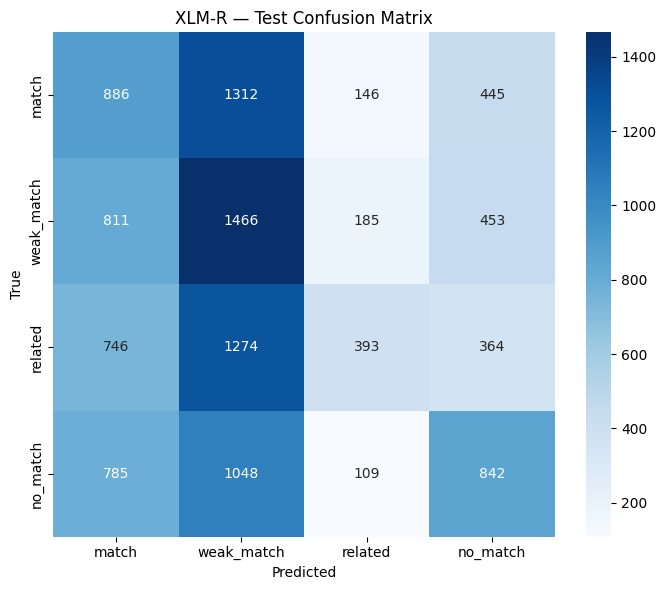

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

test_output = trainer.predict(ds_test)
test_preds = np.argmax(test_output.predictions, axis=-1)
test_labels = np.array(ds_test["label"])

label_names = [ID2LABEL[i] for i in range(NUM_LABELS)]

print(classification_report(test_labels, test_preds, target_names=label_names))

cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("XLM-R — Test Confusion Matrix")
plt.tight_layout()
plt.show()


In [17]:
SAVE_DIR = "/content/xlmr-rfq-supplier-final"

trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"Model saved to {SAVE_DIR}")
print(f"Contents: {', '.join(__import__('os').listdir(SAVE_DIR))}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /content/xlmr-rfq-supplier-final
Contents: model.safetensors, training_args.bin, config.json, tokenizer_config.json, tokenizer.json


In [18]:
import shutil

DRIVE_DEST = "/content/drive/MyDrive/xlmr-rfq-supplier-final"
shutil.copytree(SAVE_DIR, DRIVE_DEST, dirs_exist_ok=True)
print(f"Model copied to {DRIVE_DEST}")

Model copied to /content/drive/MyDrive/xlmr-rfq-supplier-final


In [19]:
from transformers import pipeline

clf_pipeline = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0,
    top_k=NUM_LABELS,  # return all class probabilities
)

sample_rfq = (
    "Title: Korktaschen, Korkrucksäcke "
    "Description: Wir suchen Hersteller von Korktaschen und Korkrucksäcken "
    "Delivery: DE Quantity: 500 "
    "Supplier types wanted: Manufacturer, Wholesaler"
)
sample_supplier = (
    "Name: Cork Factory Ltd Country: PT Area: europe "
    "Description: We produce high-quality cork bags and accessories "
    "Types: Manufacturer Products: Cork handbags, Cork backpacks "
    "Categories: Clothing and accessories "
    "Keywords: cork bags, eco-friendly, sustainable fashion"
)

# XLM-R sentence-pair: pass as a single string with </s></s> separator,
# or let the tokenizer handle it via the dict format
result = clf_pipeline({"text": sample_rfq, "text_pair": sample_supplier})
print("Prediction:")
for r in result:
    print(f"  {r['label']:>12s}: {r['score']:.4f}")

Prediction:
    weak_match: 0.3299
         match: 0.2606
      no_match: 0.2055
       related: 0.2039


In [20]:
import json

test_cases = [
  {
    "rfq_title": "Korktaschen, Korkrucksäcke, Korkreisetaschen, Korkregenschirme",
    "rfq_description": "Ich bin auf der Suche nach Korktaschen, Korkrucksäcke, Korkreisetaschen, Korkregenschirme. Anzahl: 10-50, Einmalig. Aufgeführte Korkprodukte in verschiedenen Varianten. In Portugal produziert, Nachhaltigkeit, und Lieferungen nach Deutschland",
    "delivery_location": "DE",
    "quantity": "10 - 50",
    "category_id": 100033,
    "rfq_supplier_types": "MANUFACTURER,WHOLESALER",
    "supplier_name": "FARL CORK UNIPESSOAL, LDA",
    "supplier_country": "PT",
    "distribution_area": "international",
    "supplier_description": "FARL CORK is a company established in late 2016, built on over 10 years of experience and product development in the cork industry, from the forest to the final product, with a strong commitment to environmental awareness and the preservation of the cork ecosystem.",
    "supplier_types": "Production",
    "products": "Natural yoga block,Fine grain cork block - Yoga,Cork Specialties,Granules,Corks,Cork Cylinder / Roller",
    "product_categories": "Wood and wood products",
    "keywords": "Cortiça - produtos,yoga,cortiça granulada,Rolhas de cortiça,Rolhas,Capsulados,Tapetes de ioga"
  },
  {
    "rfq_title": "High-End Leather Card Holders / Wallets",
    "rfq_description": "We are looking for a new manufacturing partner to relaunch two existing card holder / wallet models. Products: Slim card holder / wallet (2 models). Quantities: Small series, approx. 20-100 pcs per model per year. Materials: Leather will be supplied by us (box calf and exotic leathers). Quality level: Premium / luxury quality.",
    "delivery_location": "FR",
    "quantity": "20-100 pieces per model per year",
    "category_id": 100033,
    "rfq_supplier_types": "PRODUCTION",
    "supplier_name": "GUARNICIONERIA HNOS. PEDRAZA",
    "supplier_country": "ES",
    "distribution_area": "",
    "supplier_description": "WE ARE LEATHER ARTISANS, MANUFACTURING ALL TYPES OF ITEMS FOR HUNTING PRACTICE. WE USE FIRST-CLASS LEATHERS SUCH AS CALF HIDES FOR THE PRODUCTION OF RIFLE AND SHOTGUN CASES, GREASED SUEDE FOR HOLSTERS AND CASES, AND ALSO NUBUCK AND BOX-CALF TO CREATE LADIES' BAGS AND BELTS.",
    "supplier_types": "Production",
    "products": "",
    "product_categories": "Textile production",
    "keywords": ""
  },
  {
    "rfq_title": "Korktaschen, Korkrucksäcke, Korkreisetaschen, Korkregenschirme",
    "rfq_description": "Ich bin auf der Suche nach Korktaschen, Korkrucksäcke, Korkreisetaschen, Korkregenschirme. Anzahl: 10-50, Einmalig.",
    "delivery_location": "DE",
    "quantity": "10 - 50",
    "category_id": 100033,
    "rfq_supplier_types": "MANUFACTURER,WHOLESALER",
    "supplier_name": "PROMOEASO",
    "supplier_country": "ES",
    "distribution_area": "europe",
    "supplier_description": "We provide you with our online catalog featuring around 5000 references of specialized items for corporate gifts, promotional gifts, advertising gifts, and branded gifts.",
    "supplier_types": "Wholesaler",
    "products": "Shopping Bags and Promotional Backpacks,promotional umbrellas,Customized Mugs and Thermoses",
    "product_categories": "Advertising materials and advertising technology",
    "keywords": "Regalos,bolsas,mochilas,bolsas de tejidos naturales,Regalos de empresa,paraguas,tazas personalizadas"
  },
  {
    "rfq_title": "High-quality No-stick Inner Coating 1.8L + 3.5L + 6L Hot Pot Set",
    "rfq_description": "I am interested in Hot Pot Set Food Wimmer. Material: Stainless Steel. Use: food. Shape: round. Feature: Large capacity, Dishwasher safe.",
    "delivery_location": "DE",
    "quantity": "30173",
    "category_id": 100048,
    "rfq_supplier_types": "PRODUCTION",
    "supplier_name": "CONZEPT Container Modulbau & Handel GmbH",
    "supplier_country": "AT",
    "distribution_area": "international",
    "supplier_description": "",
    "supplier_types": "Production",
    "products": "Container für Schulen und Kindergärten in Modulbauweise,Bürocontainer,Sanitärcontainer,Lagercontainer,Kühlcontainer,Seecontainer",
    "product_categories": "Behälter, Logistik- & Lagerbedarf",
    "keywords": "Kindergarten,Schulen,Container,Modulbau,Kühlcontainer,Raumlösungen,Bürocontainer,Sanitärcontainer"
  }
]

# Ensure all necessary functions are available for new data
# (They were defined in cell pK42YEGE1jW6)
# def clean_array_field(s): ...
# def build_rfq_text(row) -> str: ...
# def build_supplier_text(row) -> str: ...

for i, case in enumerate(test_cases):
    # Apply clean_array_field to relevant fields before building text
    # Note: These columns might not exist or be relevant in raw test cases,
    # but for consistency with training data preprocessing, we'll ensure they are strings.
    # For simplicity, we directly convert to string and fill NaNs if any field is missing

    # Simulate cleaning for the provided dictionary structure
    processed_case = {k: (clean_array_field(v) if k in ARRAY_COLS else str(v) if pd.isna(v) else v) for k, v in case.items()}

    # Build the RFQ and Supplier text using the existing functions
    # Need to convert the dict to a pandas Series so build_rfq_text/build_supplier_text can access elements like row['rfq_title']
    case_series = pd.Series(processed_case)
    sample_rfq_test = build_rfq_text(case_series)
    sample_supplier_test = build_supplier_text(case_series)

    print(f"\n--- Test Case {i+1} ---")
    # print(f"RFQ Text: {sample_rfq_test}")
    # print(f"Supplier Text: {sample_supplier_test}")

    # Get prediction from the pipeline
    result = clf_pipeline({"text": sample_rfq_test, "text_pair": sample_supplier_test})

    print("Prediction:")
    for r in result:
        print(f"  {r['label']:>12s}: {r['score']:.4f}")


--- Test Case 1 ---
Prediction:
    weak_match: 0.2896
      no_match: 0.2851
         match: 0.2528
       related: 0.1725

--- Test Case 2 ---
Prediction:
    weak_match: 0.3708
       related: 0.2574
      no_match: 0.2205
         match: 0.1513

--- Test Case 3 ---
Prediction:
      no_match: 0.2900
    weak_match: 0.2845
         match: 0.2454
       related: 0.1801

--- Test Case 4 ---
Prediction:
    weak_match: 0.2839
       related: 0.2803
         match: 0.2459
      no_match: 0.1899
